# Elastic Net

In [1]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [2]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2

import importlib
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path


from cred import DATA_PATH_CRED
from functions_elastic_net import rolling_forecast_elastic_net, rolling_forecast_elastic_net_old
from functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 10),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")

Importy uspesne.


In [3]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")

df_exog = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_EXOG)
df_exog = df_exog.set_index("datum").sort_index()
df_exog = df_exog.asfreq("MS")
df_exog = df_exog.drop(columns=["datum"], errors="ignore")

In [4]:
X = df.drop(columns = ["pp_nonsa", "pp_sa_orig", TARGET_VAR])
y = df[TARGET_VAR]
init_train_size = len(y) - TEST_SIZE
last_train_value = float(df_pp[TARGET_VAR].iloc[init_train_size - 1])


In [6]:
elnet_res = rolling_forecast_elastic_net(
    X=X,
    y_diff=y,
    level_series=df_pp[TARGET_VAR],
    initial_train_size=init_train_size,
    refit_every=1

)

RMSE (diferencia):      2.0854
RMSE (level, onestep):  2.0854
WMAPE (level):          1.51%
ME (level):             -0.1444
Refity:                 24 / 24


In [10]:
elnet_res.keys()

dict_keys(['results', 'models_by_step', 'refit_diagnostics', 'step_diagnostics', 'misaligned_dates', 'summary', 'diagnostics'])

In [7]:
results_elnet = elnet_res["results"]
results_elnet.to_parquet("data/elnet_rest")
diagnostics = elnet_res["diagnostics"]
hp = diagnostics['hyperparams']
coef = diagnostics["coefficients"]
sparsity = diagnostics["sparsity"]
refit_diag = elnet_res["refit_diagnostics"]
summary_elnet = elnet_res["summary"]
summary_elnet = pd.DataFrame([summary_elnet])
summary_elnet.to_parquet("data/elnet_sum")

In [9]:
sparsity.reset_index(inplace=True)
coef_hist = coef.merge(
    sparsity[["forecast_date", "n_selected"]],
    on="forecast_date",
    how="left",
)

In [10]:
selected_counts = coef_hist.groupby("forecast_date")["n_selected"].first()
print(selected_counts.describe())

count    24.000000
mean     12.666667
std       1.833663
min      11.000000
25%      11.000000
50%      12.000000
75%      13.250000
max      17.000000
Name: n_selected, dtype: float64


In [11]:
top_feat = coef_hist[coef_hist["selected"]].groupby("feature")["abs_coef"].mean().sort_values(ascending = False)
top_feat


feature
trzby_priemysel_sa           1.340418
crisis_dummy                 1.077083
export_celkovy_sa            1.051725
unem_prod                    0.154557
expected_employment          0.134131
uvery_celkom                 0.127429
hdd                          0.086621
cdd                          0.075588
economic_sentiment           0.070934
sh_prices_non_sa             0.062773
kurz_usd_eur                 0.051106
cpi_nsa                      0.048907
vklady_nefinancne_podniky    0.034743
sadzba_3m_euribor            0.021205
inflation                    0.014634
expected_product_prices      0.011413
oil_price_eur                0.006255
oil_europe_usd               0.004510
foreign_demand_sa            0.001548
ipcv_priemysel               0.000273
Name: abs_coef, dtype: float64

In [14]:
Y_axis = [results_elnet["actual_diff"], results_elnet["predicted_diff"], results_elnet["actual_level"], results_elnet["predicted_level"]]
X_axis = [results_elnet.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [16,4]
num_rows = 1
num_cols = 1

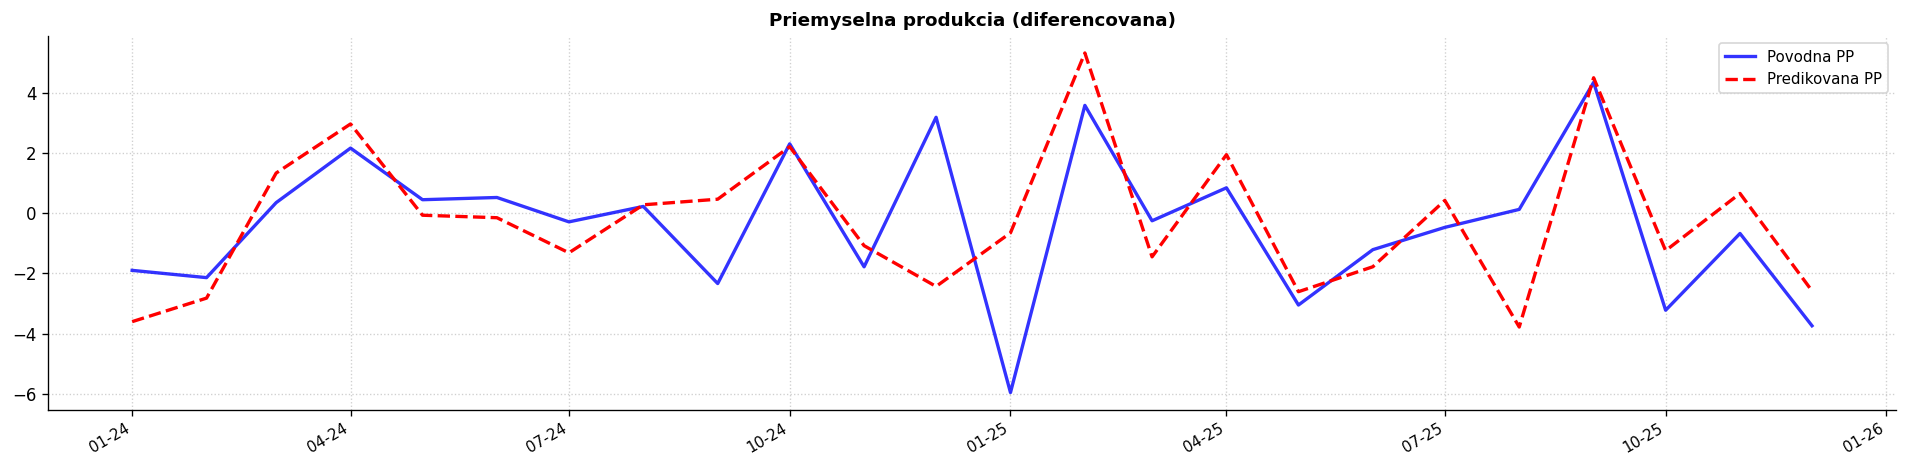

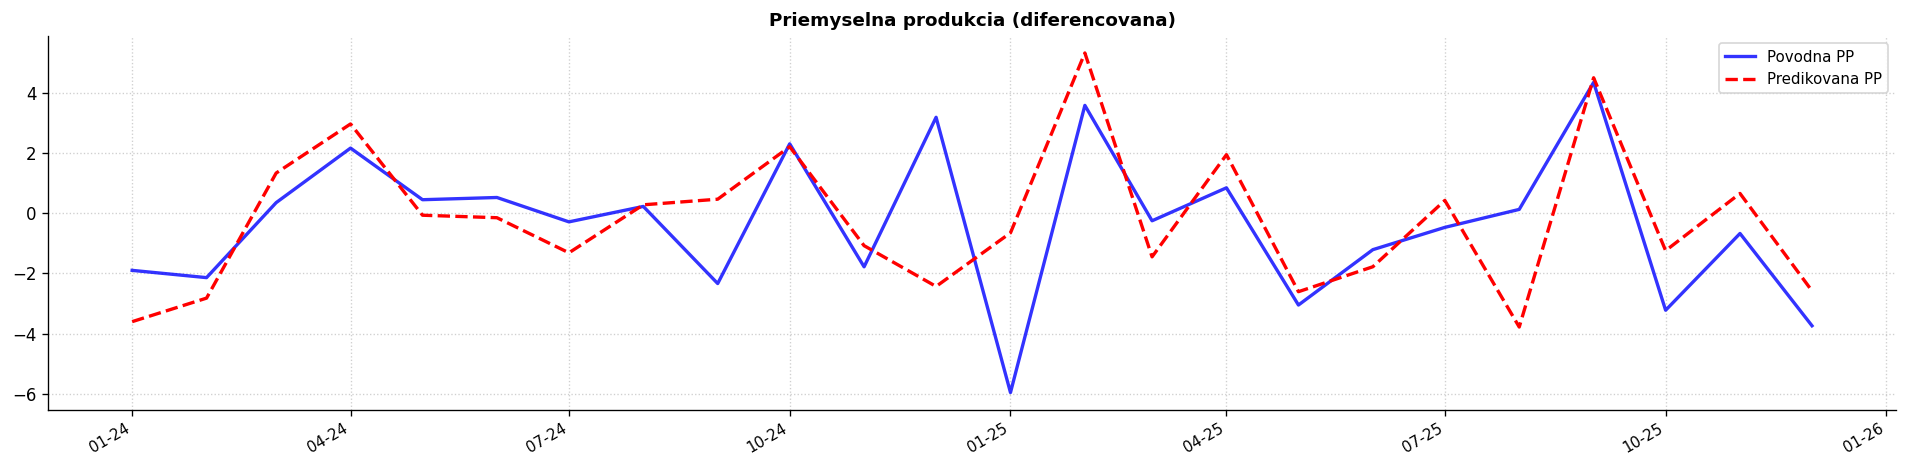

In [15]:
forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)